# Introducción a la Estadistica : Estadistica Descriptiva
---

### Cargando Librerías
---

In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.stats import norm, variation, kurtosis, skew


### Utiizamos en dataset :  "acarreo" de una Mina Subterranea 
---

In [181]:
#Visualicemos de forma general la data que tenemos (5 primeras filas)
acarreo = pd.read_excel('BD_Extraccion.xlsx',sheet_name='datos', header=1)   # utilizamos la ubicacion fisica de archivo en la pc
acarreo.head(5)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,LABOR,VOLQUETES,PLAN_SEMANAL,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,A,Zona Alta,Tajos,1910.0,OB6A,T-841B,NaN,2500.0,NaN,NaN
1,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-731B,6.0,1000.0,2500.0,1575.0
2,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-761E,5.0,2000.0,2500.0,2690.0
3,2020-01-01,A,Zona Baja,Tajos,1650.0,OB1,T-001E,8.0,2500.0,2600.0,2417.0
4,2020-01-01,A,Zona Baja,Tajos,1640.0,OB1,T-101,6.0,1500.0,2000.0,985.0


In [22]:
#Muestra los datos que faltan
acarreo.count()

FECHA             1149
TURNO             1149
ZONA              1149
TIPO_LABOR        1149
NIVEL             1144
CUERPO            1144
LABOR             1144
VOLQUETES          437
PLAN_SEMANAL       526
PLAN_DIARIO        551
ACARREO_DIARIO     990
dtype: int64

### Información de las variables
---

In [23]:
#visualicemos solo las columnas 
acarreo.columns

Index([&#39;FECHA&#39;, &#39;TURNO&#39;, &#39;ZONA&#39;, &#39;TIPO_LABOR&#39;, &#39;NIVEL&#39;, &#39;CUERPO&#39;, &#39;LABOR &#39;,
       &#39;VOLQUETES&#39;, &#39;PLAN_SEMANAL&#39;, &#39;PLAN_DIARIO&#39;, &#39;ACARREO_DIARIO&#39;],
      dtype=&#39;object&#39;)

In [12]:
#Descripcion del dataset de titanic
acarreo.info()

&lt;class &#39;pandas.core.frame.DataFrame&#39;&gt;
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   FECHA           1149 non-null   datetime64[ns]
 1   TURNO           1149 non-null   object        
 2   ZONA            1149 non-null   object        
 3   TIPO_LABOR      1149 non-null   object        
 4   NIVEL           1144 non-null   float64       
 5   CUERPO          1144 non-null   object        
 6   LABOR           1144 non-null   object        
 7   VOLQUETES       437 non-null    float64       
 8   PLAN_SEMANAL    526 non-null    float64       
 9   PLAN_DIARIO     551 non-null    float64       
 10  ACARREO_DIARIO  990 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 98.9+ KB


In [24]:
#Caclula los la cantidad de valores null por columna
acarreo.isnull().sum()

FECHA               0
TURNO               0
ZONA                0
TIPO_LABOR          0
NIVEL               5
CUERPO              5
LABOR               5
VOLQUETES         712
PLAN_SEMANAL      623
PLAN_DIARIO       598
ACARREO_DIARIO    159
dtype: int64

## df1_camion: filtramos datos de acerreo por turno
---

In [182]:
#Generamos Dataframe df1, acarreo Diario
df1 = acarreo.groupby(['FECHA','TURNO'])[('PLAN_DIARIO','ACARREO_DIARIO','VOLQUETES')].sum().reset_index(['FECHA','TURNO'])
df1_camion = df1[df1['VOLQUETES'] >10].rename(columns={'PLAN_DIARIO':'PLAN_TURNO','ACARREO_DIARIO':'ACARREO_TURNO'})
df1_camion.head(3)


,FECHA,TURNO,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
0,2020-01-01,A,9600.0,7927.0,25.0
1,2020-01-01,B,8400.0,7962.0,20.0
2,2020-01-02,A,8400.0,8543.0,18.0


### Medidas de Posición
---
* Medidas de Tendencia Central : media, mediana, moda
* Medidas de Tendencia No Central : cuartiles, deciles, percentiles



In [106]:
#Media :Es el promedio de todos los valores en los datos
#Mediana : Es el valor que se encuentra en el centro del conjunto de datos

df1_camion.describe()

,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
count,95.000000,95.000000,95.000000
mean,8701.052632,8984.210526,24.652632
std,1919.690508,1497.352535,3.783414
min,0.000000,5247.000000,11.000000
25%,8000.000000,7972.500000,22.000000
50%,9000.000000,8901.000000,25.000000
75%,10000.000000,10212.000000,27.000000
max,12200.000000,11997.000000,32.000000


## Quartiles y Deciles

---
#### Qk = Dividen al conjunto de datos en cuatro partes iguales
#### Dk = Los deciles son nueve valores (Dk; k = 1, 2, ..., 9) que dividen al conjunto de datos en diez partes iguales

In [143]:
# Percentile values in summary, include 10% and 90%
deciles = df1_camion.describe(percentiles=[.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, 1])
#deciles = df1.groupby(pd.qcut(df1.PLAN_DIARIO, 10))
#df_deciles.head(3)
deciles

,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
count,95.000000,95.000000,95.000000
mean,8701.052632,8984.210526,24.652632
std,1919.690508,1497.352535,3.783414
min,0.000000,5247.000000,11.000000
10%,6620.000000,7017.400000,20.000000
20%,7500.000000,7722.400000,21.000000
25%,8000.000000,7972.500000,22.000000
30%,8100.000000,8191.400000,23.000000
40%,8500.000000,8567.000000,24.000000
50%,9000.000000,8901.000000,25.000000


### Histogramas

---

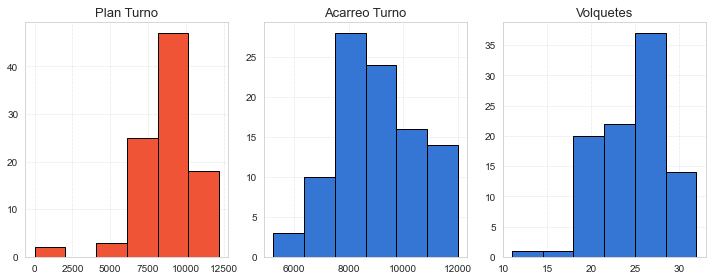

In [173]:
# Histogramas
#fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10,4), sharey=True, sharex=True)
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10,4))
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = df1_camion['PLAN_TURNO'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Turno', fontsize=13)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)

ax1.hist(x = df1_camion['ACARREO_TURNO'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax1.set_title('Acarreo Turno',fontsize=13)

ax2.hist(x = df1_camion['VOLQUETES'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax2.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax2.set_title('Volquetes',fontsize=13)


fig.tight_layout()
plt.show()

### Diagrama de Cajas : BoxPlot

---

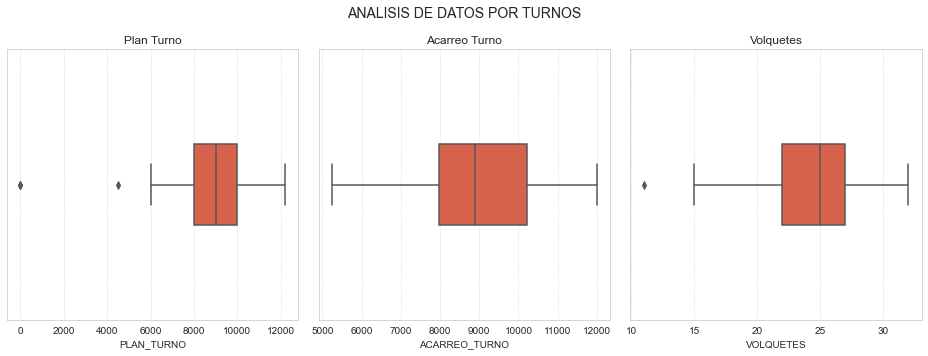

In [174]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
#sns.set(style='whitegrid')
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 3, figsize=(13,5))
fig.suptitle('ANALISIS DE DATOS POR TURNOS', fontsize=14)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( df1_camion["PLAN_TURNO"],width=0.3, ax=axes[0]).set_title('Plan Turno')  
sns.boxplot( df1_camion["ACARREO_TURNO"], width=0.3,ax=axes[1]).set_title('Acarreo Turno')
sns.boxplot( df1_camion["VOLQUETES"] ,width=0.3, ax=axes[2]).set_title('Volquetes')

fig.tight_layout()


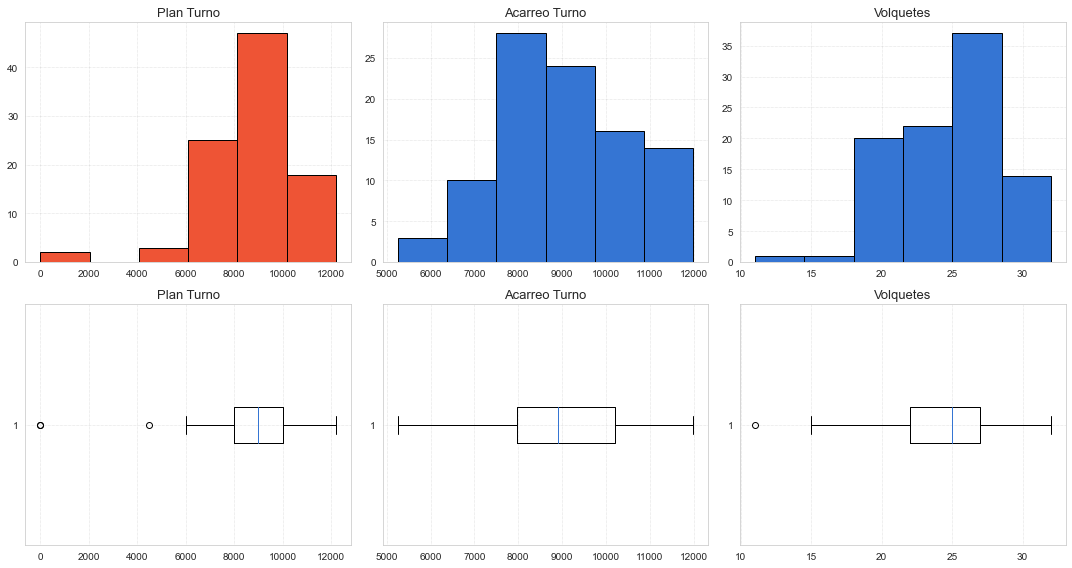

In [176]:
# Histogramas
#fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10,4), sharey=True, sharex=True)
fig, ((ax0, ax1, ax2) , (ax3, ax4, ax5)) = plt.subplots(2, 3, figsize=(15,8))
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = df1_camion['PLAN_TURNO'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Turno', fontsize=13)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)

ax1.hist(x = df1_camion['ACARREO_TURNO'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax1.set_title('Acarreo Turno',fontsize=13)

ax2.hist(x = df1_camion['VOLQUETES'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax2.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax2.set_title('Volquetes',fontsize=13)

ax3.boxplot(x = df1_camion["PLAN_TURNO"], vert=False)
ax3.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax3.set_title('Plan Turno',fontsize=13)

ax4.boxplot(x = df1_camion["ACARREO_TURNO"], vert=False)
ax4.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax4.set_title('Acarreo Turno',fontsize=13)

ax5.boxplot(x = df1_camion["VOLQUETES"], vert=False)
ax5.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax5.set_title('Volquetes',fontsize=13)

# If you don't do tight_layout() you'll have weird overlaps
fig.tight_layout()


## df2_camion: Dataframe de datos de acerreo por turno
---

In [115]:
df2 = acarreo.groupby(['FECHA','TURNO','ZONA'])[('PLAN_DIARIO','ACARREO_DIARIO','VOLQUETES')].sum().reset_index(['FECHA','TURNO','ZONA'])
df2_camion = df2[df2['VOLQUETES'] >10].rename(columns={'PLAN_DIARIO':'PLAN_TURNO','ACARREO_DIARIO':'ACARREO_TURNO'})

df2_camion.head(3)
#df2_camion.count()

,FECHA,TURNO,ZONA,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
0,2020-01-01,A,Zona Alta,5000.0,4265.0,11.0
1,2020-01-01,A,Zona Baja,4600.0,3662.0,14.0
3,2020-01-01,B,Zona Baja,3400.0,3750.0,12.0


In [138]:
df2_camion.describe()

,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
count,108.000000,108.000000,108.000000
mean,5962.962963,5912.759259,16.638889
std,1659.669632,1620.997696,3.689992
min,0.000000,2435.000000,11.000000
25%,5000.000000,4753.750000,14.000000
50%,6050.000000,6131.500000,17.000000
75%,7025.000000,7036.500000,19.000000
max,9000.000000,10706.000000,25.000000


In [142]:
#Q1 = pd.deci(df1['PLAN_DIARIO']).
print(df1_camion.quantile([0,0.25,0.5,0.75,1]))

      PLAN_TURNO  ACARREO_TURNO  VOLQUETES
0.00         0.0         5247.0       11.0
0.25      8000.0         7972.5       22.0
0.50      9000.0         8901.0       25.0
0.75     10000.0        10212.0       27.0
1.00     12200.0        11997.0       32.0


### Diagrama de Cajas : BoxPlot desglosado por zonas

---

Text(0.5, 1.0, &#39;Volquetes&#39;)

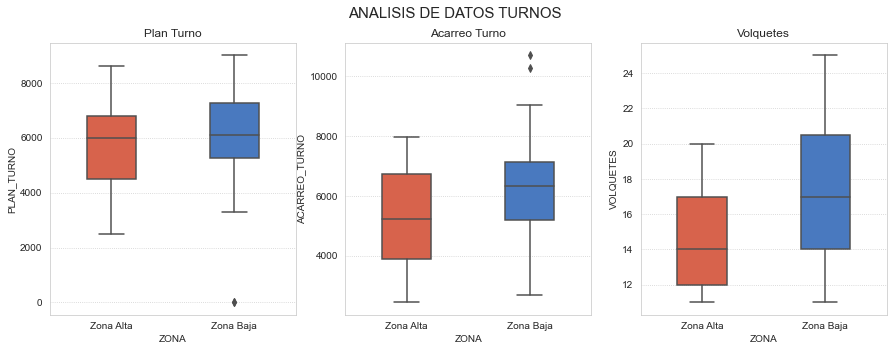

In [117]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('ANALISIS DE DATOS TURNOS', fontsize=15)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( ax=axes[0], x=df2_camion["ZONA"], y=df2_camion["PLAN_TURNO"], width=0.4).set_title('Plan Turno')  
sns.boxplot( ax=axes[1], x=df2_camion["ZONA"], y=df2_camion["ACARREO_TURNO"], width=0.4).set_title('Acarreo Turno')
sns.boxplot( ax=axes[2], x=df2_camion["ZONA"], y=df2_camion["VOLQUETES"], width=0.4).set_title('Volquetes')



### Medidas de Dispersión : Rango (R) y Rango Intercuartilico (RI)

---

In [144]:
# Range is one indicator of spread
# Rango (R) Es una medida de variabilidad que se obtiene de la diferencia entre el máximo y mínimo valor de la variable.
# To calculate range, you subtract the smallest value from the largest value
range_Plan = df1_camion['PLAN_TURNO'].max() - df2_camion['PLAN_TURNO'].min()
print(" Rango (Plan Diario) :", range_Plan)

range_Acarreo = df1_camion['ACARREO_TURNO'].max() - df2_camion['ACARREO_TURNO'].min()
print(" Rango (Acarreo Turno) :",range_Acarreo)

range_Volquete = df1_camion['VOLQUETES'].max() - df2_camion['VOLQUETES'].min()
print(" Rango (Volquetes) :",range_Volquete)


 Rango (Plan Diario) : 12200.0
 Rango (Acarreo Turno) : 9562.0
 Rango (Volquetes) : 21.0


In [145]:
#Rango Intercuartilico (RI)
#Interquartile range using scipy.stats.iqr
#Se define como la diferencia entre los cuartiles tres (Q3) y uno (Q1); Cálculo: Rango Intercuartílico (RI) es el rango en el que se encuentra el 50% central de los datos.

# Calculate Interquartile Range (IQR), 75% - 25%
IQR_Plan = ss.iqr(df1_camion['PLAN_TURNO'])
print(" Rango Intercuartílico (Plan Turno) :", IQR_Plan)

IQR_Acarreo = ss.iqr(df1_camion['ACARREO_TURNO'])
print(" Rango Intercuartílico (Acarreo Turno) :",IQR_Acarreo)

IQR_Volquetes = ss.iqr(df1_camion['VOLQUETES'])
print(" Rango Intercuartílico (Volquetes) :",IQR_Volquetes)


 Rango Intercuartílico (Plan Turno) : 2000.0
 Rango Intercuartílico (Acarreo Turno) : 2239.5
 Rango Intercuartílico (Volquetes) : 5.0


### Varianza y Desviacion Estandar 

---

In [146]:
#La desviación típica mide la dispersión de los datos respecto a la media. Se trata de la raíz cuadrada de la varianza, que en sí misma no es una medida de dispersión. Para calcular la desviación típica usamos std y var para la varianza. 

std = df1_camion['VOLQUETES'].std(ddof=1)
print ("Desviacion Estandar (Volquetes):", std.round(1))

var = df1_camion['VOLQUETES'].var(ddof=1)
print ("Varianza (Volquetes) :", var.round(1))


Desviacion Estandar (Volquetes): 3.8
Varianza (Volquetes) : 14.3


### Coeficiente de Variación

---

In [148]:
#El coeficiente de variación : es una medida que sirve para comparar entre dos muestras, cuál varía más y cuál es más estable. Es una simple división, de la desviación típica sobre la media, sin embargo, SciPy nos ofrece una función ya preparada.

coef_var = ss.variation(df1_camion['ACARREO_TURNO'])
print("Coeficiente de Variación (Acarreo) : ", round(coef_var,2))

coef_var = ss.variation(df1_camion['VOLQUETES'])
print("Coeficiente de Variación (Volquetes): ", round(coef_var,3))

Coeficiente de Variación (Acarreo) :  0.17
Coeficiente de Variación (Volquetes):  0.153


### Medidas de Asimetría

---
#### Estas medidas brindan información sobre la dirección horizontal que toma la distribución de los datos con respecto a su centro.


In [150]:
#Medidas Asimetricas : para saber si los datos estan repartidos de forma simétrica vamos a usar la función "skew" de SciPy.
#Si Ak < 0 tiene Asimetria negativa, Ak = 0 Distribucion simetrica, Ak > 0 Distribucion con Asimetria Positiva 

asimetria_Plan = skew(df1_camion['PLAN_TURNO'])
print("Valor de Asimetria (Plan): ", asimetria_Plan)

asimetria_Acarreo = skew(df1_camion['ACARREO_TURNO'])
print("Valor de Asimetria (Acarreo):", asimetria_Acarreo)

asimetria_Volquetes = skew(df1_camion['VOLQUETES'])
print("Valor de Asimetria (Volquetes):", asimetria_Volquetes)

Valor de Asimetria (Plan):  -1.9777077215592807
Valor de Asimetria (Acarreo): -0.058576008185853415
Valor de Asimetria (Volquetes): -0.6174791114786871


In [151]:
#alternativa
df1_camion.skew()

PLAN_TURNO      -2.009578
ACARREO_TURNO   -0.059520
VOLQUETES       -0.627430
dtype: float64

### Medidas de Curtosis

---
#### Estas medidas brindan información sobre la deformación vertical de una distribución de frecuencias en comparación con la curva normal
Ku > 0.263 (Distribución Leptocúrtica ) | Ku = 0.263 (Distribución Mesocúrtica ) | Ku <0.263 (Distribución Platicúrtica )

In [153]:

Kurtosis_Plan = kurtosis(df1_camion['PLAN_TURNO'])
print("Curtosis (Plan Diario): ",Kurtosis_Plan)

Kurtosis_Acarreo = kurtosis(df1_camion['ACARREO_TURNO'])
print("Curtosis (Acarreo): ",Kurtosis_Acarreo)

Kurtosis_Volquetes = kurtosis(df1_camion['VOLQUETES'])
print("Curtosis (Volquetes): ",Kurtosis_Volquetes)


Curtosis (Plan Diario):  6.981864996812213
Curtosis (Acarreo):  -0.5331693460519413
Curtosis (Volquetes):  0.626737819110124


In [154]:
#alternativa
df1_camion.kurt()

PLAN_TURNO       7.429681
ACARREO_TURNO   -0.496414
VOLQUETES        0.726938
dtype: float64

### Covarianza y Correlacion de Pearson

---

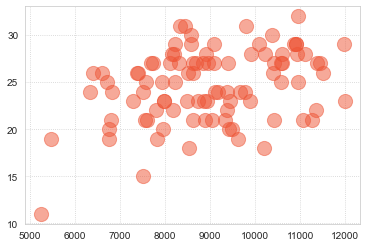

In [155]:
#Diagramas de dispersion
plt.scatter(df1_camion['ACARREO_TURNO'], df1_camion['VOLQUETES'], s=200,alpha=0.5)
plt.show()

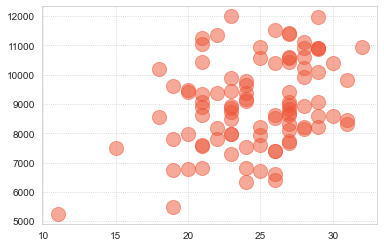

In [178]:
#Diagramas de dispersion
plt.scatter(df1_camion['VOLQUETES'], df1_camion['ACARREO_TURNO'], hue="smoker" s=200,alpha=0.5)
plt.show()

&lt;seaborn.axisgrid.FacetGrid at 0x7fb8329b8290&gt;

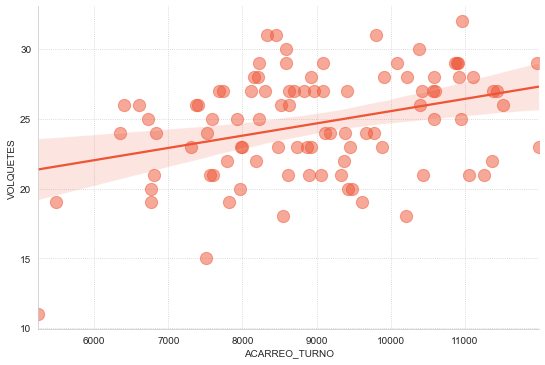

In [156]:
#La gráfica incluye además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('ACARREO_TURNO', 'VOLQUETES', data=df1_camion,aspect=1.5, scatter_kws={"s": 150, "alpha": 0.5})

&lt;seaborn.axisgrid.FacetGrid at 0x7fb836fca3d0&gt;

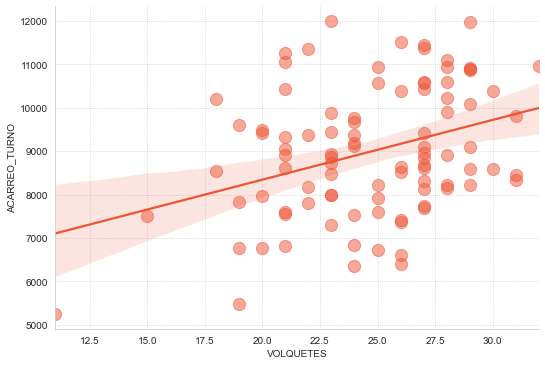

In [179]:
#La gráfica incluye además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('VOLQUETES', 'ACARREO_TURNO', data=df1_camion,aspect=1.5, scatter_kws={"s": 150, "alpha": 0.5})

In [157]:
# Covarianza
# Si Cov(x,y) > 0, hay dependencia directa (positiva), es decir a grandes valores de X corresponden grandes valores de Y.
# Si Cov(x,y) = 0, Una covarianza (0) se interpreta como la no existencia de una relación lineal entre las dos variables estudiadas.
#Si Cov(x,y) < 0, hay dependencia inversa o negativa es decir, a grandes valores de X corresponden pequeños valores de Y

cov_mat = df1_camion.cov()
cov_mat

,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
PLAN_TURNO,3.685212e+06,1.097753e+06,2572.709966
ACARREO_TURNO,1.097753e+06,2.242065e+06,1968.956887
VOLQUETES,2.572710e+03,1.968957e+03,14.314222


In [158]:
cov_mat.loc["ACARREO_TURNO", "VOLQUETES"]

1968.9568868980964

In [159]:
# Coeficiente de correlacion
# R ≅ −1: La relación entre las variables es perfecta e inversa.
# R ≅ 0: No existe relación entre las variables
# R ≅ 1: La relación entre las variables es perfecta y directa.

corr_mat = df1_camion.corr()
corr_mat

,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
PLAN_TURNO,1.000000,0.381900,0.354222
ACARREO_TURNO,0.381900,1.000000,0.347559
VOLQUETES,0.354222,0.347559,1.000000


In [160]:
corr_mat.loc["ACARREO_TURNO", "VOLQUETES"]

0.3475587882951577

### Graficos de Distribución de datos
---

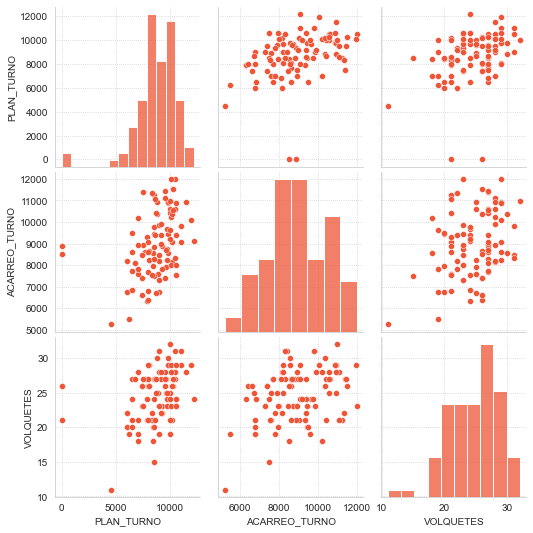

In [177]:
sns.pairplot(df1_camion)
plt.show()

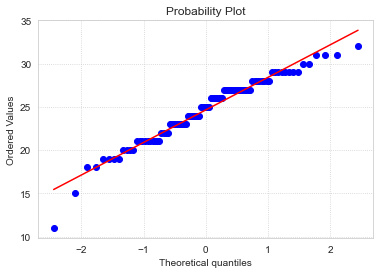

In [97]:
import pylab
#ss.probplot(df1_camion['ACARREO_DIARIO'], dist="norm",plot=pylab)
ss.probplot(df1_camion['VOLQUETES'], dist="norm",plot=pylab)
pylab.show()

La gráfica así obtenida incluye además de los datos incluye la regresión lineal y el intervalo de confianza

&lt;seaborn.axisgrid.FacetGrid at 0x7fb835f28790&gt;

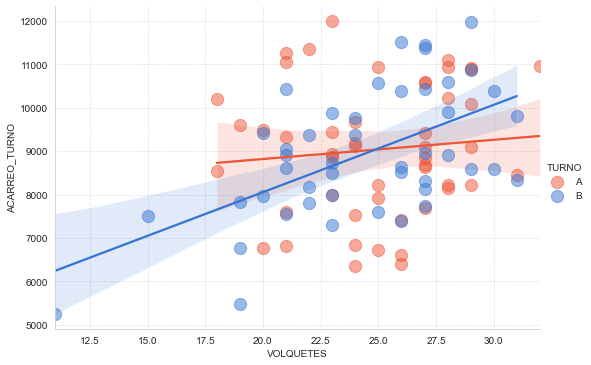

In [202]:
#La gráfica incluye además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('VOLQUETES', 'ACARREO_TURNO' , hue="TURNO", data=df1_camion, aspect=1.5, scatter_kws={"s": 150, "alpha": 0.5})

&lt;AxesSubplot:xlabel=&#39;VOLQUETES&#39;, ylabel=&#39;ACARREO_TURNO&#39;&gt;

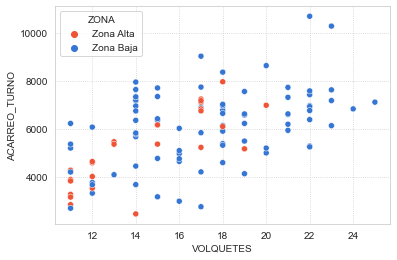

In [204]:
#Diagramas de dispersion
sns.scatterplot(x="VOLQUETES", y="ACARREO_TURNO", data=df2_camion, hue = 'ZONA' , marker = 'o')

&lt;seaborn.axisgrid.FacetGrid at 0x7fb837e57150&gt;

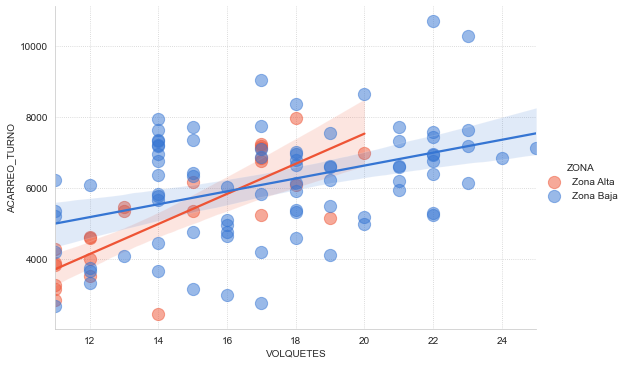

In [205]:
from seaborn import lmplot
lmplot('VOLQUETES', 'ACARREO_TURNO' , hue="ZONA", data=df2_camion, aspect=1.5, scatter_kws={"s": 150, "alpha": 0.5})

## df3_camion: Dataframe de datos de acerreo por cuerpo
---

In [206]:
df3 = acarreo.groupby(['FECHA','TURNO','ZONA','CUERPO'])[('PLAN_DIARIO','ACARREO_DIARIO','VOLQUETES')].sum().reset_index(['FECHA','TURNO','ZONA','CUERPO'])
df3_camion = df3[df3['VOLQUETES'] >10].rename(columns={'PLAN_DIARIO':'PLAN_TURNO','ACARREO_DIARIO':'ACARREO_TURNO'})

df_camion.head(3)
#df2_camion.count()

,FECHA,TURNO,ZONA,CUERPO,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
0,2020-01-01,A,Zona Alta,OB6A,5000.0,4265.0,11.0
1,2020-01-01,A,Zona Baja,OB1,4600.0,3402.0,14.0
14,2020-01-02,B,Zona Baja,OB1,4000.0,5597.0,13.0


&lt;AxesSubplot:xlabel=&#39;ACARREO_TURNO&#39;, ylabel=&#39;PLAN_TURNO&#39;&gt;

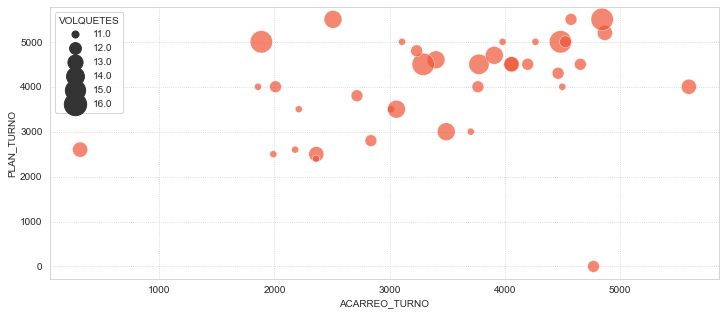

In [248]:
#Diagramas de dispersion
#sns.scatterplot(x="ACARREO_TURNO", y="PLAN_TURNO", data=df3_camion, hue = 'VOLQUETES' , marker = 'o', style = 'ZONA')
#sns.color_palette("husl", 20)
f, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(x="ACARREO_TURNO", y="PLAN_TURNO", data=df3_camion , size ='VOLQUETES', palette="muted", alpha=.7, sizes=(50, 500))


&lt;AxesSubplot:xlabel=&#39;ACARREO_TURNO&#39;, ylabel=&#39;CUERPO&#39;&gt;

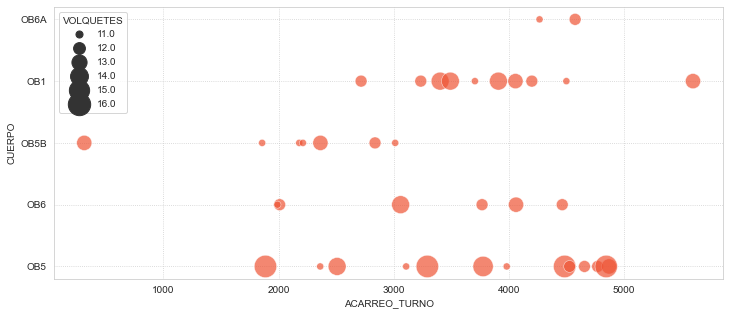

In [255]:
f, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(x="ACARREO_TURNO", y="CUERPO", data=df3_camion , size ='VOLQUETES', palette="muted", alpha=.7, sizes=(50, 500))

&lt;AxesSubplot:xlabel=&#39;ACARREO_TURNO&#39;, ylabel=&#39;PLAN_TURNO&#39;&gt;

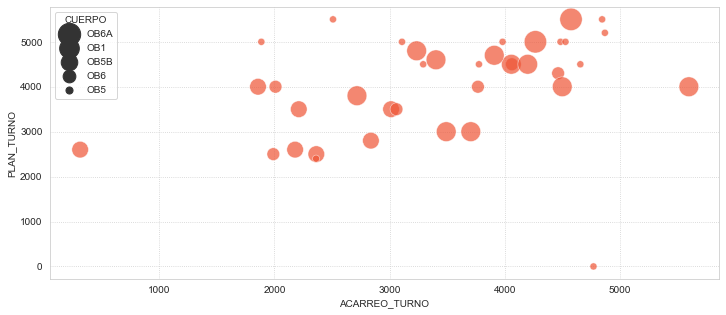

In [256]:
f, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(x="ACARREO_TURNO", y="PLAN_TURNO", data=df3_camion , size ='CUERPO', palette="muted", alpha=.7, sizes=(50, 500))

## Analises por Zonas
---

In [267]:
df3_camion.head(3)

,FECHA,TURNO,ZONA,CUERPO,PLAN_TURNO,ACARREO_TURNO,VOLQUETES
0,2020-01-01,A,Zona Alta,OB6A,5000.0,4265.0,11.0
1,2020-01-01,A,Zona Baja,OB1,4600.0,3402.0,14.0
14,2020-01-02,B,Zona Baja,OB1,4000.0,5597.0,13.0


In [269]:
#Generamos dataframe acarreo por zonas
df_zonas = df3_camion.groupby(['ZONA'])[('ACARREO_TURNO')].sum().reset_index(['ZONA'])
df_zonas.head(3)

,ZONA,ACARREO_TURNO
0,Zona Alta,17345.0
1,Zona Baja,113470.0


&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

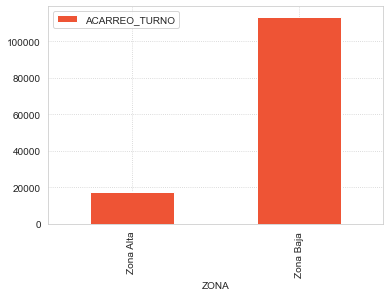

In [270]:
df_zonas.plot(x='ZONA',y='ACARREO_TURNO', kind='bar')
plt.show

In [308]:
#Generamos dataframe acarreo por zonas
df_zonas = df3_camion.groupby(['CUERPO'])[('ACARREO_TURNO')].sum().reset_index(['CUERPO'])
df_zonas.head(3)

,CUERPO,ACARREO_TURNO
0,OB1,38804.0
1,OB5,49053.0
2,OB5B,14772.0


&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

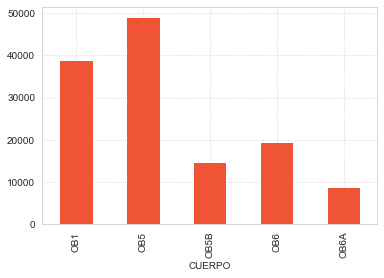

In [309]:
df_cuerpo.plot(x='CUERPO',y='ACARREO_TURNO', kind='bar')
plt.show

&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

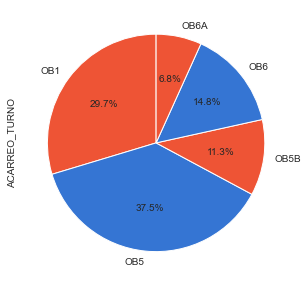

In [312]:
#df_cuerpo.plot(x='CUERPO',y='ACARREO_TURNO', kind='pie',autopct='%1.1f%%', startangle=90)
#plt.show
df_cuerpo.plot.pie(y='ACARREO_TURNO',figsize=(5, 5),autopct='%1.1f%%', startangle=90)
plt.show